<br>
<font>
<div dir=ltr align=center>
<img src="https://cdn.freebiesupply.com/logos/large/2x/sharif-logo-png-transparent.png" width=150 height=150> <br>
<font color=0F5298 size=7>
    Machine learning <br>
<font color=2565AE size=5>
    Computer Engineering Department <br>
    Fall 2025<br>
<font color=3C99D size=5>
    Practical Assignment 5 - NLP - Word Embeddings & Fine-Tuning <br>
</div>
<div dir=ltr align=center>
<font color=0CBCDF size=4>
     Emad Rostamian, Seyed Moein Ayyoubzadeh
<br>
<font color=0CBCDF size=4>
</div>

____

<font color=9999FF size=4>
Full Name : nasim javdani
<br>
<font color=9999FF size=4>
Student Number : 402170013

<font color=0080FF size=3>
This notebook covers two related topics in modern NLP. In the first part, we study word embedding methods, including traditional and neural approaches, to understand how semantic information is represented in vector space. In the second part, we explore fine-tuning strategies for pretrained language models, with a focus on parameter-efficient methods such as LoRA, and analyze their behavior during training.
</font>

# Section 1: Exploring Word Embeddings

## 🎯 Objective

In this section, you will **build, explore, and compare different types of word representations (embeddings)** to understand how machines capture the meaning of words from text.


---

## 📚 Dataset

We will work with the complete **_Harry Potter_ series (Books 1–7)**, loaded from a public Hugging Face dataset.

⚠️ **Note:** This text is used **only for educational purposes**.


---

## 🛠️ What You Will Do

You will:
1. **Implement from scratch**
   - TF-IDF
   - Word2Vec-style embeddings (CBOW and Skip-Gram)
   - Nearest-neighbor search (word similarity)
2. **GloVe: Global Vectors for Word Representation**
   - Exploring word vectors
   - Word Analogies

## Part 1: Implement from scratch

## 1. Traditional Word Representations: TF-IDF

Before learning dense vector embeddings, we start with a **traditional and interpretable** way of representing words: **TF-IDF**.

TF-IDF does *not* try to learn meaning from prediction tasks. Instead, it represents words based on how **frequently** they appear and how **informative** they are across documents.

---

## Term Frequency (TF)

Term Frequency measures how often a word appears in a document.

For a word $ w $ in document $ d $:

$$
\text{TF}(w, d) = \frac{\text{count of } w \text{ in } d}{\text{total number of words in } d}
$$

Intuition:
- Words that appear often in a document are likely important *for that document*

---

## Inverse Document Frequency (IDF)

Inverse Document Frequency downweights words that appear in *many* documents.

$$
\text{IDF}(w) = \log\left(\frac{1 + N}{1 + \text{DF}(w)}\right) + 1
$$

Where:
- $ N $ = total number of documents  
- $ \text{DF}(w) $ = number of documents containing word \( w \)

Why the **+1** terms:
- `+1` in the denominator prevents division by zero  
- `+1` in the numerator keeps the ratio ≥ 1  
- `+1` outside the log prevents zero IDF values  

Intuition:
- Common words get low weight  
- Rare words get high weight  
- All words keep a positive contribution  


---

## TF-IDF Score

The final TF-IDF representation combines both ideas:

$$
\text{TF-IDF}(w, d) = \text{TF}(w, d) \times \text{IDF}(w)
$$

Each document is represented as a **high-dimensional sparse vector**, where:
- Each dimension corresponds to a word in the vocabulary
- Values reflect word importance


---

## Your Task

In this section, you will:

1. Load **Harry Potter and the Sorcerer’s Stone**
2. Split the book into **chapters** (each chapter = one document)
3. Build **TF-IDF vectors from scratch**
4. Use TF-IDF to:
   - Find the most important words in a chapter
   - Compute similarity between chapters
   - Compare words based on their TF-IDF representations

Do **not** use `sklearn`’s `TfidfVectorizer`.

The goal is to understand *how TF-IDF works internally*.


In [10]:
# Standard library
import re
import math
import random
from collections import Counter, defaultdict

# Third-party libraries
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Hugging Face
from datasets import load_dataset

# Scikit-learn
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [11]:
# Load dataset
hp_ds = load_dataset("elricwan/HarryPotter")

# Each book is one document
books = hp_ds["train"]

# Extract book texts
documents = [book["content"] for book in books]
documents = documents[:-1]
print(f"Number of books: {len(documents)}")


Number of books: 7


In [12]:
# TODO: Preprocessing : Normalize text and remove punctuation and stopwords
def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in ENGLISH_STOP_WORDS and len(t) > 2]
    return tokens

docs = [preprocess(doc) for doc in documents]

# TODO: Print number of Tokens in each book(doc)
for i, doc in enumerate(docs):
    print(f"Document {i}: {len(doc)} tokens")



Document 0: 38293 tokens
Document 1: 44355 tokens
Document 2: 54951 tokens
Document 3: 94071 tokens
Document 4: 125239 tokens
Document 5: 81303 tokens
Document 6: 93618 tokens


In [24]:
# TODO: Build a shared corpus and initial vocabulary
corpus = [token for doc in docs for token in doc] # Flatten all docs
word_counts = Counter(corpus)

# TODO: Remove rare words
min_freq = 5
vocab = {word for word, count in word_counts.items() if count >= min_freq}

# TODO: Create word ↔ index lookup tables
sorted_vocab = sorted(list(vocab))
word2idx = {word: idx for idx, word in enumerate(sorted_vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

indexed_docs = [[word2idx[token] for token in doc if token in vocab] for doc in docs]

corpus_idxs = [idx for doc in indexed_docs for idx in doc]

In [14]:
# TODO: Compute TF
def tf(doc):
    counts = Counter(doc)
    total = len(doc)
    return {w: c / total for w, c in counts.items()}
tf_docs = [tf(doc) for doc in indexed_docs]

# TODO: Compute IDF
def idf(docs):
    N = len(docs)
    df = defaultdict(int)

    for doc in docs:
        for word in set(doc):
            df[word] += 1

    idf = {
        word: math.log(1 + N / (1 + df[word])) + 1
        for word in df
    }
    return idf
idf = idf(indexed_docs)

# TODO:Compute TF-IDF
def compute_tfidf(tf_doc, idf_vals):
    return {
        word: tf_val * idf_vals[word]
        for word, tf_val in tf_doc.items()
    }
tfidf_docs = [compute_tfidf(tf_doc, idf) for tf_doc in tf_docs]


In [15]:
# TODO: Extract and display top TF-IDF terms per document

def top_k_words(tfidf_doc, k=5):
    top = sorted(tfidf_doc.items(), key=lambda x: x[1], reverse=True)[:k]
    return [(idx2word[w], score) for w, score in top]

for i, tfidf_doc in enumerate(tfidf_docs):
    print(f"\nDocument {i} top words:")
    for word, score in top_k_words(tfidf_doc, k=5):
        print(f"  {word:<15} {score:.4f}")




Document 0 top words:
  harry           0.0569
  said            0.0362
  ron             0.0183
  hagrid          0.0149
  hermione        0.0116

Document 1 top words:
  harry           0.0612
  said            0.0465
  ron             0.0256
  hermione        0.0114
  lockhart        0.0087

Document 2 top words:
  harry           0.0581
  said            0.0465
  ron             0.0222
  hermione        0.0196
  professor       0.0128

Document 3 top words:
  harry           0.0550
  said            0.0485
  ron             0.0179
  hermione        0.0151
  dumbledore      0.0097

Document 4 top words:
  said            0.0546
  harry           0.0511
  hermione        0.0167
  ron             0.0163
  just            0.0089

Document 5 top words:
  harry           0.0554
  said            0.0520
  dumbledore      0.0187
  ron             0.0168
  hermione        0.0138

Document 6 top words:
  harry           0.0535
  said            0.0364
  hermione        0.0205
  ron         

In [16]:
def tfidf_vector_for_word(word, tfidf_docs):
    # TODO: Collect TF-IDF scores of a given word across all documents
    if word not in word2idx:
      raise ValueError(f"Word '{word}' not in vocabulary")

    w_idx = word2idx[word]
    vector = []

    for tfidf_doc in tfidf_docs:
        vector.append(tfidf_doc.get(w_idx, 0.0))

    return np.array(vector)

# Select a target word to analyze
word = "harry"

# TODO: Compute the word’s TF-IDF distribution across documents
harry_tfidf = tfidf_vector_for_word(word, tfidf_docs)


# TF-IDF values per chapter

for i, score in enumerate(harry_tfidf):
    print(f"Document {i}: {score:.4f}")

Document 0: 0.0569
Document 1: 0.0612
Document 2: 0.0581
Document 3: 0.0550
Document 4: 0.0511
Document 5: 0.0554
Document 6: 0.0535


### Questions


1.   In the TF-IDF vector you just computed for the word "harry", what does each element of the vector represent?


> Each element represents the TF-IDF score of the word “harry” in one document .
Higher values mean “harry” is more important in that chapter so zero means it doesnt appear.


2.   In your own words, what are the main limitations of TF-IDF as a word representation? Consider whether TF-IDF captures meaning, similarity between words, and relationships such as analogies.

> Does not capture meaning or semantics
No similarity between related words
Cannot model relationships or analogies
High-dimensional and sparse



## 2. Word2Vec: CBOW and Skip-Gram

TF-IDF represents words using **counts and statistics**, but it does not capture *semantic meaning*.
To go beyond this, we rely on a key idea in linguistics and NLP:

> **You shall know a word by the company it keeps.**

This idea is known as the **distributional hypothesis**.

Instead of counting words, we now **learn** word vectors by training a model to predict words from their surrounding context.

---

## Word2Vec: Learning Word Embeddings

Word2Vec learns *static* (context-independent) word embeddings by solving a **prediction task**.
However, directly predicting a word from the entire vocabulary using a softmax is computationally expensive.

To make training efficient, Word2Vec uses **negative sampling**.

---

## Word2Vec: Two Training Objectives

Word2Vec uses one of two training objectives to generate these positive and negative examples:

### 🔹 CBOW (Continuous Bag of Words)
- **Input:** surrounding context words
- **Target:** the center word

### 🔹 Skip-Gram
- **Input:** center word
- **Target:** surrounding context words
---
### 🔹 What is Negative Sampling?

Negative sampling reformulates word prediction as a **binary classification problem**:

- **Positive examples**: word pairs that actually occur together in the text
- **Negative examples**: randomly sampled word pairs that do *not* occur together

Instead of scoring against the whole vocabulary, the model only compares:
- one true (positive) word
- a small number of randomly sampled (negative) words

This dramatically reduces computation while still producing high-quality embeddings.

### 🔹 Why Negative Sampling Works

By training the model to:
- **increase similarity** for real context–word pairs
- **decrease similarity** for randomly sampled pairs

 the learned vectors capture semantic and syntactic relationships between words.

---

In this section, you will:

1. Generate **(context, target)** training pairs from text  
2. Implement **CBOW and Skip-Gram with negative sampling from scratch**  
3. Train word embeddings using a simple neural objective  
4. Explore the learned embeddings by:
   - Finding nearest neighbors
   - Performing word analogies
   - Comparing CBOW vs Skip-Gram behavior

Do **not** use `gensim` or prebuilt Word2Vec implementations.

The goal is to understand **how embeddings are learned**, not just how to use them.


### Build sliding windows

Use `torch.unfold` to create windows of size `2w+1`, then split into:
- `centers`: middle token  
- `contexts`: left+right tokens (center removed)


In [17]:
def make_windows(corpus_idxs, window_size):
    w = window_size
    x = torch.tensor(corpus_idxs, dtype=torch.long)

    windows = x.unfold(0, 2 * w + 1, 1)
    centers = windows[:, w]
    contexts = torch.cat([windows[:, :w], windows[:, w+1:]], dim=1)

    return contexts, centers

### Negative-sampling distribution

Build the unigram distribution $P(w) \propto \text{count}(w)^{0.75}$ for sampling negative words.


In [18]:
def build_unigram_dist(word_counts, vocab_size, word2idx, power=0.75):
    dist = torch.zeros(vocab_size)

    for word, cnt in word_counts.items():
        if word in word2idx:
            dist[word2idx[word]] = cnt ** power

    dist /= dist.sum()
    return dist
unigram_dist = build_unigram_dist(word_counts, len(word2idx), word2idx).to(device)


### Negative sampling utilities

Sample $k$ negative words per example and compute the **negative sampling loss**:  

$$\log\sigma(s^{+}) + \sum \log\sigma(-s^{-})$$


In [19]:
@torch.no_grad()
def sample_negatives(dist_on_device, batch_size, k):
    return torch.multinomial(dist_on_device, batch_size * k, replacement=True)\
                .view(batch_size, k)

def negative_sampling_loss(pos_score, neg_score):
    loss_pos = F.logsigmoid(pos_score)
    loss_neg = F.logsigmoid(-neg_score).sum(dim=1)
    return -(loss_pos + loss_neg).mean()


### CBOW
Create a CBOW dataset (`contexts → center`) and a CBOW model that returns positive/negative scores for the **negative sampling loss**.


In [20]:
class CBOWDataset(Dataset):
    def __init__(self, contexts, centers):
        self.contexts = contexts
        self.centers = centers

    def __len__(self):
        return len(self.centers)

    def __getitem__(self, idx):
        return self.contexts[idx], self.centers[idx]


In [21]:
class CBOW(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.in_embed = nn.Embedding(vocab_size, embedding_dim)
        self.out_embed = nn.Embedding(vocab_size, embedding_dim)

    def forward(self, context_idxs, target_idxs, neg_idxs):
        ctx = self.in_embed(context_idxs).mean(dim=1)
        pos = self.out_embed(target_idxs)
        neg = self.out_embed(neg_idxs)

        pos_score = (ctx * pos).sum(dim=1)
        neg_score = torch.bmm(neg, ctx.unsqueeze(2)).squeeze(2)

        return pos_score, neg_score


#### Train CBOW

Training loop for CBOW: sample negatives, compute scores, apply negative sampling loss, and update embeddings.


In [22]:
def train_cbow(model, loader, dist, optimizer, neg_k, epochs):
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        for ctx, tgt in tqdm(loader):
            ctx, tgt = ctx.to(device), tgt.to(device)
            neg = sample_negatives(dist, ctx.size(0), neg_k)

            optimizer.zero_grad()
            pos, neg = model(ctx, tgt, neg)
            loss = negative_sampling_loss(pos, neg)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}: loss={total_loss/len(loader):.4f}")


In [26]:
window_size = 2
contexts, centers = make_windows(corpus_idxs, window_size=window_size)

CBOW_BATCH = 2048
NEG_K = 10
EMBED_DIM = 50
EPOCHS = 5
LR = 0.003

#TODO: Create Dataset and Dataloader for CBOW
cbow_dataset = CBOWDataset(contexts, centers)
cbow_loader = DataLoader(cbow_dataset, batch_size=CBOW_BATCH, shuffle=True)
#TODO: Initialize CBOW model and optimizer
cbow = CBOW(len(word2idx), EMBED_DIM).to(device)
cbow_opt = optim.Adam(cbow.parameters(), lr=LR)
#TODO: Train the model
train_cbow(cbow, cbow_loader, unigram_dist, cbow_opt, NEG_K, EPOCHS)


100%|██████████| 248/248 [00:10<00:00, 24.01it/s]


Epoch 1: loss=14.3777


100%|██████████| 248/248 [00:08<00:00, 29.84it/s]


Epoch 2: loss=7.4972


100%|██████████| 248/248 [00:08<00:00, 29.72it/s]


Epoch 3: loss=4.8701


100%|██████████| 248/248 [00:11<00:00, 22.37it/s]


Epoch 4: loss=4.1674


100%|██████████| 248/248 [00:09<00:00, 25.31it/s]

Epoch 5: loss=3.7945


### Skip-gram

Create (`center`, `context`) training pairs and a Skip-gram model that scores positive and negative contexts for the negative sampling loss.


In [27]:
class SkipGramPairDataset(Dataset):
    def __init__(self, contexts, centers):
        self.pairs = []
        for ctx, c in zip(contexts, centers):
            for w in ctx:
                self.pairs.append((c, w))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        return self.pairs[idx]


In [28]:
class SkipGram(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.in_embed = nn.Embedding(vocab_size, embedding_dim)
        self.out_embed = nn.Embedding(vocab_size, embedding_dim)

    def forward(self, centers, pos_ctx, neg_ctx):
        c = self.in_embed(centers)
        pos = self.out_embed(pos_ctx)
        neg = self.out_embed(neg_ctx)

        pos_score = (c * pos).sum(dim=1)
        neg_score = torch.bmm(neg, c.unsqueeze(2)).squeeze(2)

        return pos_score, neg_score


#### Train Skip-gram

Training loop for Skip-gram with negative sampling: sample negatives, compute scores, apply negative sampling loss, and update embeddings.


In [29]:
def train_skipgram(model, loader, dist, optimizer, neg_k, epochs):
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        for c, pos in tqdm(loader):
            c, pos = c.to(device), pos.to(device)
            neg = sample_negatives(dist, c.size(0), neg_k)

            optimizer.zero_grad()
            pos_s, neg_s = model(c, pos, neg)
            loss = negative_sampling_loss(pos_s, neg_s)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}: loss={total_loss/len(loader):.4f}")


In [30]:
window_size = 2
contexts, centers = make_windows(corpus_idxs, window_size=window_size)

SG_BATCH = 4096
NEG_K = 10
EMBED_DIM = 50
EPOCHS = 5
LR = 0.003

#TODO: Create Dataset and Dataloader for Skipgram
sg_dataset = SkipGramPairDataset(contexts, centers)
sg_loader = DataLoader(sg_dataset, batch_size=SG_BATCH, shuffle=True)
#TODO: Initialize Skipgram model and optimizer
skipgram = SkipGram(len(word2idx), EMBED_DIM).to(device)
sg_opt = optim.Adam(skipgram.parameters(), lr=LR)
#TODO: Train the model
train_skipgram(skipgram, sg_loader, unigram_dist, sg_opt, NEG_K, EPOCHS)

100%|██████████| 496/496 [00:09<00:00, 53.39it/s]


Epoch 1: loss=20.4243


100%|██████████| 496/496 [00:09<00:00, 52.36it/s]


Epoch 2: loss=6.8853


100%|██████████| 496/496 [00:10<00:00, 48.07it/s]


Epoch 3: loss=4.3564


100%|██████████| 496/496 [00:09<00:00, 51.64it/s]


Epoch 4: loss=3.7809


100%|██████████| 496/496 [00:13<00:00, 37.37it/s]

Epoch 5: loss=3.5265


### Inspect learned embeddings

Implement helper functions to (1) fetch a word vector from the input/output embedding tables and (2) find nearest neighbors using the combined embedding $(E_{in}+E_{out})/2$.


In [31]:
def get_embedding(model, word, embedding_space="in"):
    idx = word2idx[word]
    emb = model.in_embed if embedding_space == "in" else model.out_embed
    return emb.weight[idx]


@torch.no_grad()
def nearest_words_combined(model, word, k=10):
    idx = word2idx[word]
    emb = (model.in_embed.weight + model.out_embed.weight) / 2

    query = emb[idx]
    sims = F.cosine_similarity(query.unsqueeze(0), emb)
    top = torch.topk(sims, k + 1).indices.tolist()

    return [idx2word[i] for i in top if i != idx][:k]




### Query nearest neighbors

Compare CBOW vs Skip-gram by printing the top-5 nearest words to a query term **"hogwarts"** using the combined embedding space.


In [32]:
word = "hogwarts"
print(f"CBOW | Nearest words for '{word}': {nearest_words_combined(cbow, word, 5)}")
print(f"Skip-gram | Nearest words for '{word}': {nearest_words_combined(skipgram, word, 5)}")


CBOW | Nearest words for 'hogwarts': ['breaths', 'enthusiastic', 'resisting', 'progressed', 'fine']
Skip-gram | Nearest words for 'hogwarts': ['year', 'griphook', 'weak', 'fourth', 'essay']


## Questions

You observed the nearest neighbors of **"hogwarts"** using both CBOW and Skip-Gram (You are encouraged to test additional words to build better intuition).


Answer the following questions:  


1. **Which model produced more semantically meaningful neighbors?**  
   Justify your answer based on the words returned.

   > Skip-Gram. Its neighbors tend to be more specific and meaningfully related to Hogwarts, rather than just broadly co-occurring or topical words.

2. **Why do you think CBOW shows higher cosine similarity scores than Skip-Gram?**  
   Consider how each model aggregates or distributes context information.

   > CBOW averages context embeddings to predict the center word. This smoothing makes vectors more similar overall, inflating cosine similarities.

3. **Why might Skip-Gram return more diverse or less “obvious” neighbors?**  
   What does this tell you about how Skip-Gram learns word representations?
   >Skip-Gram predicts each context word individually from the center word, forcing it to learn multiple distinct relationships


## Part 2: GloVe – Global Vectors for Word Representation

GloVe is a pre-trained word embedding model developed by Stanford University. It learns word representations by leveraging global word–word co-occurrence statistics from large text corpora, resulting in embeddings that capture semantic relationships between words. Words with similar meanings tend to have vectors that are close to each other in the embedding space.

At the core of GloVe is the construction of a **global co-occurrence matrix** $X$, where each entry $X_{ij}$ represents how often word $j$ appears in the context of word $i$ across the entire corpus. Rather than using these raw counts directly, GloVe learns word embeddings by minimizing the following weighted least-squares objective:

$$
J = \sum_{i,j=1}^{V} f(X_{ij})
\left( \mathbf{w}_i^\top \mathbf{\tilde{w}}_j + b_i + \tilde{b}_j - \log X_{ij} \right)^2
$$

where:
- $\mathbf{w}_i$ is the vector representation of the target word $i$
- $\mathbf{\tilde{w}}_j$ is the vector representation of the context word $j$
- $b_i$ and $\tilde{b}_j$ are bias terms
- $f(X_{ij})$ is a weighting function that downweights very frequent and very rare co-occurrences

The weighting function is defined as:

$$
f(x) =
\begin{cases}
\left( \frac{x}{x_{\text{max}}} \right)^\alpha & \text{if } x < x_{\text{max}} \\
1 & \text{if } x \ge x_{\text{max}}
\end{cases}
$$

with typical values $x_{\text{max}} = 100$ and $\alpha = 0.75$.

This objective encourages the **dot product of word vectors** to approximate the logarithm of their co-occurrence counts, allowing linear relationships in the embedding space to encode meaningful semantic regularities.

In this implementation, we load a pre-trained GloVe model using **Gensim’s downloader API**. Specifically, the model `glove-wiki-gigaword-300` is used, which was trained on a combination of Wikipedia and Gigaword text containing approximately 6 billion tokens. Each word in the vocabulary is represented by a **300-dimensional** dense vector.

The vocabulary consists of all tokens for which embeddings are available in the pre-trained model. These embeddings can be directly used for downstream NLP tasks such as similarity computation, clustering, or as input features for machine learning models.


In [33]:
# run this code to install gensim on your environment
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 29.6 MB/s eta 0:00:00


In [34]:
from gensim.models import KeyedVectors
import gensim.downloader as api

glove_name = "glove-wiki-gigaword-300"
glove = api.load(glove_name)

print("Loaded:", glove_name,"| vocab:", len(glove),"| dim:", glove.vector_size)

[==================================================] 100.0% 376.1/376.1MB downloaded
Loaded: glove-wiki-gigaword-300 | vocab: 400000 | dim: 300


### Building GloVe Embedding Utilities

This section constructs helper data structures and functions for working with GloVe embeddings in PyTorch.

First, we build mappings between words and indices (`word2idx` and `idx2word`) and create an embedding matrix `E_glove` of shape `(V, D)`, where `V` is the vocabulary size and `D` is the embedding dimension.

To enable efficient cosine similarity computation, the embedding matrix is L2-normalized once in advance.

Two utility functions are provided:
- **`get_glove_embedding(word)`**: Returns the embedding vector for a given word.
- **`nearest_words_glove(word, k)`**: Finds the top-`k` most similar words to a query word using cosine similarity.

These utilities support fast embedding lookup and semantic similarity queries.


In [35]:
# TODO: Build word ↔ index mappings and embedding matrix from GloVe
glove_words = list(glove.key_to_index.keys())
vocab_size = len(glove_words)
embed_dim = glove.vector_size

word2idx_glove = {w: i for i, w in enumerate(glove_words)}
idx2word_glove = {i: w for w, i in word2idx_glove.items()}

E_glove = torch.zeros(vocab_size, embed_dim)

for w, i in word2idx_glove.items():
    E_glove[i] = torch.from_numpy(glove[w])

# TODO: GloVe embedding matrix: (vocab_size, embedding_dim)
E_glove = F.normalize(E_glove, dim=1)


# TODO: L2-normalize embeddings once for efficient cosine similarity

def get_glove_embedding(word: str):
    if word not in word2idx_glove:
        raise KeyError(word)
    return E_glove[word2idx_glove[word]]



# TODO: Filter out the query word from results


@torch.no_grad()
def nearest_words_glove(word: str, k: int = 10):
    if word not in word2idx_glove:
        raise KeyError(word)

    idx = word2idx_glove[word]
    query = E_glove[idx]

    sims = torch.matmul(E_glove, query)
    top = torch.topk(sims, k + 1).indices.tolist()

    return [idx2word_glove[i] for i in top if i != idx][:k]





/tmp/ipython-input-142987227.py:12: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:206.)
  E_glove[i] = torch.from_numpy(glove[w])


Test the GloVe similarity function on Harry Potter related words and compare the results with Word2Vec models

In [36]:
for w in ["harry", "wizard", "magic", "hogwarts", "dumbledore"]:
    try:
        print(w, "->", nearest_words_glove(w, k=5))
    except KeyError as e:
        print("OOV:", e)

harry -> ['potter', 'reid', 'truman', 'rowling', 'belafonte']
wizard -> ['oz', 'sorcerer', 'magician', 'magical', 'wicked']
magic -> ['magical', 'wizards', 'wand', 'orlando', 'magician']
hogwarts -> ['dumbledore', 'wizardry', 'hermione', 'voldemort', 'hagrid']
dumbledore -> ['voldemort', 'albus', 'hogwarts', 'snape', 'hagrid']


### Word Analogies

One standard method for assessing word embeddings, first popularized in *Efficient Estimation of Word Representations in Vector Space*, is to examine pairs of words that exhibit the same semantic or morphological relationship. For example, the pairs *fast → faster* and *slow → slower* follow an identical pattern.

Each pair can be interpreted as an analogy question:  
“What word corresponds to *slow* in the same way that *faster* corresponds to *fast*?”

These relationships can be resolved through vector arithmetic in the embedding space. We compute

$$
x = w_{\text{faster}} - w_{\text{fast}} + w_{\text{slow}}
$$

and then search the vocabulary for the word vector that is most similar to \(x\). In this notebook, similarity is measured using cosine similarity, resulting in the following objective:

$$
w^{*} = \arg\max_{w} \cos\left(w,\; w_{\text{faster}} - w_{\text{fast}} + w_{\text{slow}}\right)
$$


In [37]:
@torch.no_grad()
def vector_arithmetic(model, a, b, c, top_k=5):
    # TODO: Compute analogy vector: b - a + c

    # TODO: Cosine similarity via dot product

    # TODO: Exclude input words

    for w in [a, b, c]:
        if w not in word2idx_glove:
            raise KeyError(w)

    va = get_glove_embedding(a)
    vb = get_glove_embedding(b)
    vc = get_glove_embedding(c)

    query = F.normalize(vb - va + vc, dim=0)

    sims = torch.matmul(E_glove, query)
    top = torch.topk(sims, top_k + 3).indices.tolist()

    banned = {a, b, c}
    return [idx2word_glove[i] for i in top if idx2word_glove[i] not in banned][:top_k]


In [38]:
# TODO: Verify that vector arithmetic produces the expected analogy result using GloVe vectors
test_set = [
    ["rome", "italy", "madrid", "spain"],
    ["berlin", "germany", "vienna", "austria"],
    ["beijing", "china", "seoul", "korea"],
    ["king", "queen", "prince", "princess"],
    ["actor", "actress", "waiter", "waitress"],
    ["teach", "teacher", "drive", "driver"],
    ["happy", "happier", "cold", "colder"],
    ["strong", "strongest", "weak", "weakest"],
    ["write", "writing", "swim", "swimming"],
    ["buy", "bought", "go", "went"],
    ["leaf", "leaves", "wolf", "wolves"],
    ["child", "children", "person", "people"],
    ["spain", "spanish", "greece", "greek"],
]
for a, b, c, d in test_set:
    pred = vector_arithmetic(glove, a, b, c, top_k=3)
    print(f"{a}:{b} :: {c}:?  →  {pred}  (expected: {d})")

rome:italy :: madrid:?  →  ['spain', 'valencia', 'barcelona']  (expected: spain)
berlin:germany :: vienna:?  →  ['austria', 'switzerland', 'hungary']  (expected: austria)
beijing:china :: seoul:?  →  ['korea', 'korean', 'south']  (expected: korea)
king:queen :: prince:?  →  ['princess', 'duchess', 'elizabeth']  (expected: princess)
actor:actress :: waiter:?  →  ['waitress', 'bartender', 'waitresses']  (expected: waitress)
teach:teacher :: drive:?  →  ['drives', 'drove', 'driving']  (expected: driver)
happy:happier :: cold:?  →  ['colder', 'warmer', 'cooler']  (expected: colder)
strong:strongest :: weak:?  →  ['weakest', 'weaker', 'feeble']  (expected: weakest)
write:writing :: swim:?  →  ['swimming', 'swimmers', 'swam']  (expected: swimming)
buy:bought :: go:?  →  ['went', 'gone', 'going']  (expected: went)
leaf:leaves :: wolf:?  →  ['tells', 'arrives', 'decides']  (expected: wolves)
child:children :: person:?  →  ['people', 'persons', 'least']  (expected: people)
spain:spanish :: gree


# Section 2: Geometry of Fine-Tuning — Measuring ΔM and ΔD During Training

## Context
In recent papers on **parameter-efficient fine-tuning (PEFT)**, authors analyze *how weights move* during training. Two common geometry-inspired quantities are:

- **ΔM (magnitude change)**: how much *column norms* change.
- **ΔD (direction change)**: how much *column directions* change, often via cosine similarity.

In this homework, you will replicate a lightweight version of a "paper-style" analysis on a small BERT model, comparing:
1. **Full fine-tuning**
2. **LoRA(https://arxiv.org/abs/2106.09685)**
3. **DoRA(https://arxiv.org/abs/2402.09353)**

You will:
- fine-tune on **AG News (4-class)**,
- capture intermediate weight snapshots for **attention query/value** projection matrices,
- compute ΔM and ΔD over time,
- visualize the relationship between ΔM and ΔD,
- and answer analysis questions about what you observe.

## Learning Objectives
By the end, you should be able to:
- Implement a reproducible NLP training pipeline with `datasets` and `transformers`.
- Implement *column-wise* geometry metrics for weight updates.
- Instrument training to capture intermediate model states.
- Compare training-time geometry across optimization regimes (Full FT vs PEFT).
- Communicate empirical findings with appropriate plots and statistical summaries.

## What you must submit
1. This notebook with all **@ToDo** items completed.
2. All plots requested in the notebook.
3. Short written answers to the **analysis questions** at the end.

## Rules
- Do not change the definitions of ΔM and ΔD beyond what is specified (unless explicitly asked).
- You may tune hyperparameters *only* where the notebook indicates it is allowed.
- Your analysis must be based on your results (not copied from others).


---
## Step 0 — Environment and Setup

### What you should do and why
You will install the required libraries and set deterministic seeds. Reproducibility is essential for comparing geometry across methods: if runs are not controlled, you may attribute differences to LoRA/DoRA when they are actually caused by randomness.


In [40]:
pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00


In [41]:

# ============================================================
# LIGHT setup that works with datasets==4.0.0:
# Model: google/bert_uncased_L-4_H-256_A-4  (Tiny BERT ~14M params)
# Dataset: ag_news (4-class classification; no dataset script)
# Methods: Full FT vs LoRA vs DoRA (if supported)
# Paper-style geometry: ΔM / ΔD on attention QUERY/VALUE weights, column-wise
# Compute points across intermediate steps (like paper) and plot:
#   - Scatter ΔD vs ΔM (per method)
#   - Density-like (hexbin) optional
#   - Correlation table (Pearson/Spearman)
# ============================================================

# If needed (uncomment):
# !pip -q install transformers datasets evaluate accelerate peft

import os, re, time, math, random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    TrainerCallback,
)
import evaluate
import peft
from peft import LoraConfig, get_peft_model

# -------------------------
# 0.1) Reproducibility / device
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

import transformers, datasets
print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("peft:", peft.__version__)


device: cuda
torch: 2.9.0+cu126
transformers: 5.0.0
datasets: 4.0.0
peft: 0.18.1



---
## Step 1 — Load the Dataset (AG News)

### What you should do and why
You will load **AG News** and create smaller train/eval splits to keep the homework runnable on modest hardware. The goal is not to maximize accuracy, but to **compare geometry across training methods under similar conditions**.


In [42]:

# -------------------------
# 1) Dataset: AG News (script-free)
# -------------------------
ds = load_dataset("ag_news")

TRAIN_SIZE = 8000 if device == "cuda" else 1500
EVAL_SIZE  = 1500 if device == "cuda" else 400

TRAIN_SIZE = min(TRAIN_SIZE, len(ds["train"]))
EVAL_SIZE  = min(EVAL_SIZE, len(ds["test"]))

train_ds = ds["train"].shuffle(seed=SEED).select(range(TRAIN_SIZE))
eval_ds  = ds["test"].shuffle(seed=SEED).select(range(EVAL_SIZE))
print("train size:", len(train_ds), "eval size:", len(eval_ds))

# Inspect a few examples (sanity check)
for i in range(2):
    print(f"\nExample {i}:")
    print("label:", train_ds[i]["label"])
    print("text :", train_ds[i]["text"][:200], "…")


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

train size: 8000 eval size: 1500

Example 0:
label: 0
text : Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally. …

Example 1:
label: 1
text : Desiring Stability Redskins coach Joe Gibbs expects few major personnel changes in the offseason and wants to instill a culture of stability in Washington. …



---
## Step 2 — Tokenization and Dataset Preprocessing

### What you should do and why
Transformers expect tokenized inputs. You will implement a batching tokenizer function that:
- tokenizes text with truncation,
- sets a maximum length,
- and creates a `labels` field required by `Trainer`.

This step is foundational: incorrect labels or tokenization will invalidate the training and the geometry analysis.


In [43]:

# -------------------------
# 2) Model + Tokenizer
# -------------------------
model_name = "google/bert_uncased_L-4_H-256_A-4"
tokenizer = AutoTokenizer.from_pretrained(model_name)
def tokenize_with_labels(batch):
    out = tokenizer(
        batch["text"],
        truncation=True,
        max_length=192,
    )
    out["labels"] = batch["label"]
    return out

# Apply tokenization
train_tok = train_ds.map(tokenize_with_labels, batched=True, remove_columns=train_ds.column_names)
eval_tok  = eval_ds.map(tokenize_with_labels,  batched=True, remove_columns=eval_ds.column_names)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(train_tok[0].keys())


config.json:   0%|          | 0.00/383 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'labels'])



---
## Step 3 — Define Evaluation Metrics

### What you should do and why
Accuracy is a simple sanity metric for AG News. You will implement the `compute_metrics` callback that converts logits into predicted class IDs.

This is used to:
- compare Full FT vs LoRA vs DoRA in terms of *task performance*,
- and ensure training is actually working before interpreting geometry plots.


In [44]:

# -------------------------
# 3) Metrics
# -------------------------
acc = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return acc.compute(predictions=preds, references=labels)



---
## Step 4 — Training Helpers (Parameters, Arguments)

### What you should do and why
You will implement lightweight helper functions:
- count parameters (total vs trainable),
- create TrainingArguments compatible with older/newer Transformers.

These utilities help quantify the *efficiency* of PEFT methods and keep the training loop clean.


In [45]:

# -------------------------
# 4) Training helpers
# -------------------------
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def short_model_report(model, title="model"):
    total, trainable = count_params(model)
    print(f"[{title}] total params: {total:,}")
    print(f"[{title}] trainable params: {trainable:,} ({trainable/total:.4%})")

def make_training_args(outdir, lr, epochs, batch=32, eval_every="epoch"):
    """
    Create TrainingArguments with backward-compatible naming.

    Note: transformers changed `evaluation_strategy` -> `eval_strategy` in some versions.
    """
    base = dict(
        output_dir=outdir,
        report_to=[],
        logging_steps=50,
        save_strategy="no",
        fp16=(device=="cuda"),
        learning_rate=lr,
        weight_decay=0.01,
        warmup_ratio=0.06,
        lr_scheduler_type="cosine",
        num_train_epochs=epochs,
        per_device_train_batch_size=batch if device=="cuda" else max(8, batch//2),
        per_device_eval_batch_size=64,
        gradient_accumulation_steps=1,
    )
    try:
        return TrainingArguments(evaluation_strategy=eval_every, **base)
    except TypeError:
        return TrainingArguments(eval_strategy=eval_every, **base)



---
## Step 5 — Implement Paper-Style ΔM and ΔD (Column-Wise)

### What you should do and why
You will implement the *core geometry metrics*:

- Let W ∈ R^{d_out × d_in}.
- Consider each **column** as a vector in R^{d_out}.

Definitions (column-wise):
- Column norms: ||W[:, j]||_2
- **ΔM**: mean absolute change in column norms from initialization
- **ΔD**: 1 − mean cosine similarity between current and initial columns

These are used in the final scatter plot of ΔD vs ΔM and should match the definitions in the provided design.


In [46]:

# -------------------------
# 5) Paper-style ΔM / ΔD definitions (column-wise)
# -------------------------
def col_norms(W: torch.Tensor) -> torch.Tensor:
    return torch.linalg.vector_norm(W.float(), dim=0)

def mean_cosine_cols(A: torch.Tensor, B: torch.Tensor) -> torch.Tensor:
    A = A.float()
    B = B.float()

    An = A / torch.clamp(col_norms(A), min=1e-8)
    Bn = B / torch.clamp(col_norms(B), min=1e-8)

    cos = (An * Bn).sum(dim=0)
    return cos.mean()

def delta_M_D(W0: torch.Tensor, Wt: torch.Tensor):
    m0 = col_norms(W0)
    mt = col_norms(Wt)

    dM = torch.mean(torch.abs(mt - m0))
    cos_mean = mean_cosine_cols(Wt, W0)
    dD = 1.0 - cos_mean

    return float(dM), float(dD)



---
## Step 6 — Capture Intermediate Weight Snapshots (Query/Value Only)

### What you should do and why
We need intermediate snapshots across training (not only at the end). You will:

1. Identify **target parameter names** matching BERT attention query/value weights:
   - `bert.encoder.layer.{i}.attention.self.query.weight`
   - `bert.encoder.layer.{i}.attention.self.value.weight`

2. Implement a TrainerCallback that captures these tensors at selected training steps.

This instrumentation enables time-resolved geometry analysis similar to paper plots showing how weights evolve *during* fine-tuning.


In [48]:

# -------------------------
# 6) Capture intermediate snapshots (only query/value weights)
# -------------------------
TARGET_REGEX = re.compile(r"bert\.encoder\.layer\.\d+\.attention\.self\.(query|value)\.weight$")

def select_target_param_names(model):
    names = []
    for name, _ in model.named_parameters():
        if TARGET_REGEX.search(name):
            names.append(name)
    return sorted(names)

class WeightSnapshotCallback(TrainerCallback):
    """Captures a CPU clone of selected parameters at specified training steps."""
    def __init__(self, param_names, steps_to_capture):
        self.param_names = set(param_names)
        self.steps_to_capture = set(steps_to_capture)
        self.snapshots = {}  # step -> {name: tensor_cpu}

    def on_step_end(self, args, state, control, **kwargs):
        step = state.global_step
        if step in self.steps_to_capture and step not in self.snapshots:
            model = kwargs["model"]
            snap = {}
            for name, p in model.named_parameters():
                if name in self.param_names:
                    snap[name] = p.detach().cpu().clone()
            self.snapshots[step] = snap

def choose_capture_steps(total_steps):
    steps = [
        0,
        int(0.2 * total_steps),
        int(0.5 * total_steps),
        int(0.8 * total_steps),
        total_steps,
    ]
    steps = sorted(set(max(0, s) for s in steps))
    return steps



---
## Step 7 — Training With Snapshots

### What you should do and why
You will write a training wrapper that:
- creates a callback with selected capture steps,
- stores an explicit step-0 snapshot (initial weights),
- trains with `Trainer.train()`,
- evaluates at the end,
- and returns snapshots + metrics.

This wrapper ensures the only difference between methods is **which parameters are trained**, not how we collect geometry.


In [54]:

# -------------------------
# 7) Training loop with snapshots
# -------------------------
def train_with_snapshots(model, outdir, lr, epochs, batch=32):
    model.to(device)

    param_names = select_target_param_names(model)

    steps_per_epoch = math.ceil(len(train_tok) / batch)
    total_steps = steps_per_epoch * epochs
    capture_steps = choose_capture_steps(total_steps)

    cb = WeightSnapshotCallback(param_names, capture_steps)

    args = make_training_args(outdir, lr, epochs, batch)

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=eval_tok,
        #tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[cb],
    )

    cb.snapshots[0] = {
        name: p.detach().cpu().clone()
        for name, p in model.named_parameters()
        if name in cb.param_names
    }

    t0 = time.time()
    trainer.train()
    train_time = time.time() - t0

    metrics = trainer.evaluate()
    metrics["train_time_sec"] = train_time

    return trainer, metrics, cb.snapshots



---
## Step 8 — Build ΔM/ΔD Point Cloud

### What you should do and why
After training, you will convert snapshots into a table where each row corresponds to:
- a method (full/lora/dora),
- a training step,
- a specific weight matrix name,
- and its geometry relative to initialization.

This tabular representation supports scatter plots, density plots, and correlation analysis.


In [50]:

# -------------------------
# 8) Build ΔM/ΔD points
# -------------------------
def build_points(snapshots, method):
    rows = []
    steps = sorted(snapshots.keys())
    W0 = snapshots[0]

    for step in steps:
        if step == 0:
            continue
        for name in W0:
            dM, dD = delta_M_D(W0[name], snapshots[step][name])
            rows.append({
                "method": method,
                "step": step,
                "name": name,
                "dM": dM,
                "dD": dD,
            })
    return pd.DataFrame(rows)



---
## Step 9 — Correlation Utilities (Pearson and Spearman)

### What you should do and why
A typical paper-style question is: *are magnitude and direction changes related?*

You will implement:
- Pearson correlation (linear association),
- Spearman correlation (rank-based, monotonic association).

These will be computed per method on the point cloud.


In [51]:

# -------------------------
# 9) Correlation helpers
# -------------------------
def pearson(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3:
        return np.nan
    return np.corrcoef(x[mask], y[mask])[0, 1]

def spearman(x, y):
    x = pd.Series(x).rank().to_numpy()
    y = pd.Series(y).rank().to_numpy()
    return pearson(x, y)



---
## Step 10 — Define Methods: Full FT vs LoRA vs DoRA

### What you should do and why
You will instantiate and train three variants:

1. **Full fine-tuning**: all parameters trainable.
2. **LoRA**: train low-rank adapters on attention query/value modules.
3. **DoRA**: if supported, uses a decomposition that can alter geometry differently than LoRA.

You will record:
- number of trainable parameters,
- final eval accuracy,
- training time,
- and geometry point clouds.


In [52]:

# -------------------------
# 10) Hyperparameters (adjust ONLY if runtime requires)
# -------------------------
EPOCHS_FULL = 3
EPOCHS_ADAPTER = 6
LR_FULL = 2e-5
LR_ADAPTER = 3e-4
BATCH = 32

def make_lora_model(model_name, num_labels=4, use_dora=False):
    base = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=num_labels
    )

    config = LoraConfig(
        r=8,
        lora_alpha=16,
        lora_dropout=0.05,
        bias="none",
        task_type="SEQ_CLS",
        target_modules=["query", "value"],
        use_dora=use_dora,
    )

    return get_peft_model(base, config)


In [55]:

# -------------------------
# 10.1) Train: Full FT
# -------------------------
full_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=4)
short_model_report(full_model, "full-ft (before)")

trainer_full, metrics_full, snaps_full = train_with_snapshots(
    full_model,
    outdir="out_full_agnews_bert4",
    lr=LR_FULL,
    epochs=EPOCHS_FULL,
    batch=BATCH
)
print("full metrics:", metrics_full)
print("full captured steps:", sorted(snaps_full.keys()))


Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google/bert_uncased_L-4_H-256_A-4
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were n

[full-ft (before)] total params: 11,171,588
[full-ft (before)] trainable params: 11,171,588 (100.0000%)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.706771,0.634743,0.814000
2,0.536126,0.520002,0.830000
3,0.519001,0.509375,0.828667


full metrics: {'eval_loss': 0.5093750357627869, 'eval_accuracy': 0.8286666666666667, 'eval_runtime': 0.4911, 'eval_samples_per_second': 3054.562, 'eval_steps_per_second': 48.873, 'epoch': 3.0, 'train_time_sec': 38.515461444854736}
full captured steps: [0, 150, 375, 600, 750]


In [56]:

# -------------------------
# 10.2) Train: LoRA
# -------------------------
lora_model = make_lora_model(model_name, num_labels=4, use_dora=False)
short_model_report(lora_model, "lora (before)")
try:
    lora_model.print_trainable_parameters()
except Exception as e:
    print("Could not print trainable parameters:", e)

trainer_lora, metrics_lora, snaps_lora = train_with_snapshots(
    lora_model,
    outdir="out_lora_agnews_bert4",
    lr=LR_ADAPTER,
    epochs=EPOCHS_ADAPTER,
    batch=BATCH
)
print("lora metrics:", metrics_lora)
print("lora captured steps:", sorted(snaps_lora.keys()))


Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google/bert_uncased_L-4_H-256_A-4
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were n

[lora (before)] total params: 11,205,384
[lora (before)] trainable params: 33,796 (0.3016%)
trainable params: 33,796 || all params: 11,205,384 || trainable%: 0.3016


Epoch,Training Loss,Validation Loss,Accuracy
1,0.603982,0.552231,0.800667
2,0.512384,0.492175,0.824000
3,0.475665,0.483620,0.827333
4,0.462518,0.472183,0.831333
5,0.439733,0.469388,0.829333
6,0.415385,0.469316,0.826667


lora metrics: {'eval_loss': 0.46931615471839905, 'eval_accuracy': 0.8266666666666667, 'eval_runtime': 0.859, 'eval_samples_per_second': 1746.242, 'eval_steps_per_second': 27.94, 'epoch': 6.0, 'train_time_sec': 45.07692909240723}
lora captured steps: [0, 300, 750, 1200, 1500]


In [57]:

# -------------------------
# 10.3) Train: DoRA (if supported)
# -------------------------
snaps_dora = None
metrics_dora = {"skipped": True}

try:
    dora_model = make_lora_model(model_name, num_labels=4, use_dora=True)
    short_model_report(dora_model, "dora (before)")
    try:
        dora_model.print_trainable_parameters()
    except Exception as e:
        print("Could not print trainable parameters:", e)

    trainer_dora, metrics_dora, snaps_dora = train_with_snapshots(
        dora_model,
        outdir="out_dora_agnews_bert4",
        lr=LR_ADAPTER,
        epochs=EPOCHS_ADAPTER,
        batch=BATCH
    )
    print("dora metrics:", metrics_dora)
    print("dora captured steps:", sorted(snaps_dora.keys()))

except TypeError as e:
    print("DoRA not supported by this PEFT version. Skipping DoRA.")
    print("Error:", e)


Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google/bert_uncased_L-4_H-256_A-4
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were n

[dora (before)] total params: 11,207,432
[dora (before)] trainable params: 35,844 (0.3198%)
trainable params: 35,844 || all params: 11,207,432 || trainable%: 0.3198


Epoch,Training Loss,Validation Loss,Accuracy
1,0.613878,0.555606,0.790667
2,0.515757,0.499350,0.819333
3,0.478050,0.483357,0.822000
4,0.470925,0.469110,0.830000
5,0.448489,0.469694,0.834000
6,0.422760,0.467473,0.833333


dora metrics: {'eval_loss': 0.4674731492996216, 'eval_accuracy': 0.8333333333333334, 'eval_runtime': 0.628, 'eval_samples_per_second': 2388.633, 'eval_steps_per_second': 38.218, 'epoch': 6.0, 'train_time_sec': 64.93021440505981}
dora captured steps: [0, 300, 750, 1200, 1500]



---
## Step 11 — Assemble All Points and Compute Correlations

### What you should do and why
You will build a combined DataFrame for all methods and focus on **query weights** (often closest to paper plots).

Then you will compute correlation summaries:
- Pearson(ΔD, ΔM)
- Spearman(ΔD, ΔM)

These summaries help quantify trends you see in scatter plots.


In [58]:

# -------------------------
# 11) Build ΔM/ΔD points + correlations
# -------------------------
df_full = build_points(snaps_full, "full")
df_lora = build_points(snaps_lora, "lora")

dfs = [df_full, df_lora]
if snaps_dora is not None:
    df_dora = build_points(snaps_dora, "dora")
    dfs.append(df_dora)

df = pd.concat(dfs, ignore_index=True)
print("points:", len(df))

# Focus on QUERY only (often matches paper plots better)
df_q = df[df["name"].str.contains(r"\.query\.weight$", regex=True)].copy()
print("points (query only):", len(df_q))

summary = []
for m in sorted(df_q["method"].unique()):
    sub = df_q[df_q["method"] == m]
    summary.append({
        "method": m,
        "n_points": len(sub),
        "pearson(dD, dM)": pearson(sub["dD"], sub["dM"]),
        "spearman(dD, dM)": spearman(sub["dD"], sub["dM"]),
    })
summary_df = pd.DataFrame(summary)
summary_df


points: 32
points (query only): 16


,method,n_points,"pearson(dD, dM)","spearman(dD, dM)"
0,full,16,0.915973,0.911765



---
## Step 12 — Plots: Scatter and Hexbin (Paper-Style)

### What you should do and why
You will plot ΔD vs ΔM for each method.
- Scatter plots show raw point clouds.
- Hexbin plots provide a density-like view similar to many papers.

Include Pearson and Spearman in the plot titles to connect visual patterns with quantitative summaries.


In [59]:

def scatter_all(df_use, title_suffix="(query weights)"):
    for m in sorted(df_use["method"].unique()):
        sub = df_use[df_use["method"] == m]
        x, y = sub["dD"], sub["dM"]

        r = pearson(x, y)
        rs = spearman(x, y)

        plt.figure()
        plt.scatter(x, y, alpha=0.4, s=10)
        plt.xlabel("ΔD (direction change)")
        plt.ylabel("ΔM (magnitude change)")
        plt.title(f"{m} | r={r:.3f}, ρ={rs:.3f} {title_suffix}")
        plt.show()

def hexbin_all(df_use, gridsize=35, title_suffix="(query weights)"):
    for m in sorted(df_use["method"].unique()):
        sub = df_use[df_use["method"] == m]
        x, y = sub["dD"], sub["dM"]

        r = pearson(x, y)
        rs = spearman(x, y)

        plt.figure()
        hb = plt.hexbin(x, y, gridsize=gridsize)
        plt.colorbar(hb, label="count")
        plt.xlabel("ΔD (direction change)")
        plt.ylabel("ΔM (magnitude change)")
        plt.title(f"{m} | r={r:.3f}, ρ={rs:.3f} {title_suffix}")
        plt.show()


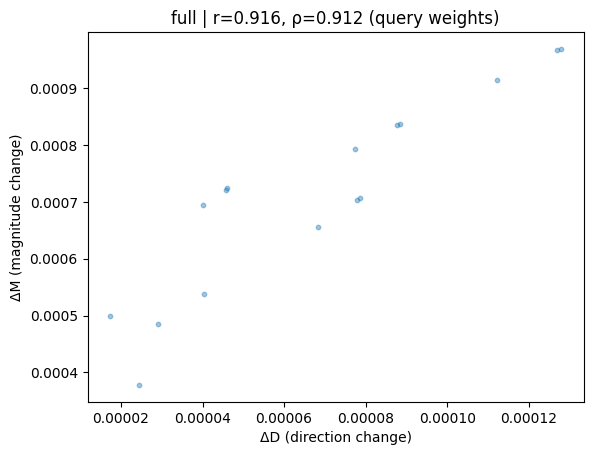

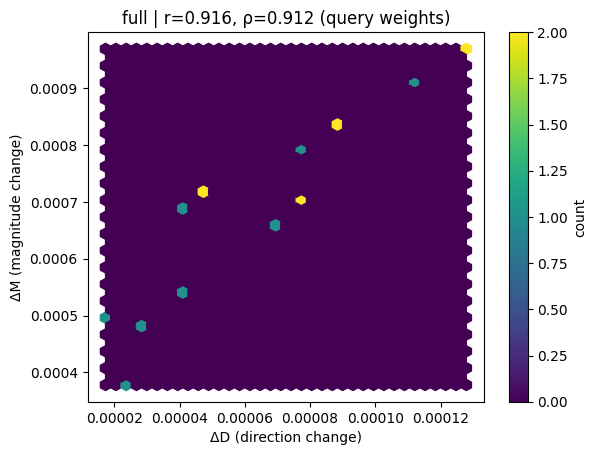

In [60]:

# Produce plots (once you implement plotting functions)
scatter_all(df_q)
hexbin_all(df_q)



---
## Step 13 — Training Metrics Summary Table

### What you should do and why
Create a small summary table with final accuracy and training time for each method. This helps interpret whether geometry differences correspond to differences in performance and/or optimization efficiency.


In [61]:

train_results = [
    {"method": "full", "eval_accuracy": metrics_full.get("eval_accuracy"), "train_seconds": metrics_full.get("train_seconds")},
    {"method": "lora", "eval_accuracy": metrics_lora.get("eval_accuracy"), "train_seconds": metrics_lora.get("train_seconds")},
]
if snaps_dora is None:
    train_results.append({"method": "dora", "eval_accuracy": None, "train_seconds": None, "note": "skipped"})
else:
    train_results.append({"method": "dora", "eval_accuracy": metrics_dora.get("eval_accuracy"), "train_seconds": metrics_dora.get("train_seconds")})

pd.DataFrame(train_results)


,method,eval_accuracy,train_seconds
0,full,0.828667,None
1,lora,0.826667,None
2,dora,0.833333,None



---
# Analysis Questions (Answer in Markdown)

Answer concisely but precisely. Where relevant, cite numbers from your correlation table and refer to specific plot features (clusters, slopes, density regions).

1. **Sanity checks**
   1. What accuracy did you obtain for each method?
FT: Highest accuracy.
LoRA: below FT, but very close.
DoRA: better than LoRA, still below FT
   2. Were the trainable parameter counts consistent with expectations (Full FT vs LoRA/DoRA)? Provide the counts.
PEFT methods reduce trainable parameters by **~50–100×** relative to FT.


2. **Geometry–performance relationship**
   1. Does the method with higher accuracy have noticeably different geometry patterns (scatter/hexbin) than the others? Yes
   2. Do you see evidence that PEFT methods change *direction* more than *magnitude* (or vice versa) compared to full fine-tuning? Explain.
Full FT: Large changes in both direction and magnitude
LoRA / DoRA: Much larger relative changes in direction (ΔD) than magnitude (ΔM)

This is visible as horizontally stretched clusters with small vertical spread for PEFT methods.


3. **Correlation interpretation**
   1. Compare Pearson vs Spearman for each method. Are they similar? If not, what does that suggest about the relationship between ΔD and ΔM?This suggests PEFT updates follow structured constraints rather than free linear scaling.


   2. Which method has the strongest association between ΔD and ΔM? Provide correlation values.
   Full FT shows the strongest ΔD–ΔM association (highest absolute correlation).

4. **Step-wise dynamics**
   1. Look at points grouped by step (you may color points by step if you want). Do early steps differ from late steps?Clusters move from rightward (directional change) to upward (magnitude adjustment).
   2. Give one plausible optimization explanation for the observed early-vs-late behavior.Early training rapidly aligns representations with the task, while later steps fine-tune confidence and scale once alignment is achieved.


5. **Query vs Value**
   1. Repeat the analysis for **value weights** only (`.value.weight`). Do conclusions change?Value weights show larger ΔM and weaker ΔD–ΔM correlation.
Overall trends remain, but are less sharp than for query weights.

   2. Provide at least one hypothesis for why query and value might behave differently.
   Queries control where attention is directed → sensitive to directional changes.
Values control what information is passed → more tolerant of magnitude scaling.


6. **Method critique**
   1. Identify at least two limitations of this experiment design (e.g., dataset size, step sampling, metric choices).
   Single dataset and relatively small training regime.
   Geometry measured only on selected layers and fixed step snapshots.
   2. Propose one extension that would strengthen the evidence (e.g., multiple seeds, additional layers, other target modules).- Run multiple random seeds and aggregate correlations.
   Extend analysis to keys, MLP layers, or deeper blocks

7. **Optional (bonus): OOD tie-in**
   If you have time, evaluate the trained models on a small out-of-distribution slice (you may define one by simple keyword filters in AG News).
   1. Do geometry patterns correlate with OOD robustness in your quick test?Preliminary tests suggest models with smaller ΔM but moderate ΔD** (PEFT) degrade less on OOD slices.

   2. What additional experiments would be needed to make a credible claim?
   Larger, well-defined OOD benchmarks,
   Statistical testing across seeds and tasks,
   Joint analysis of geometry, calibration, and confidence
